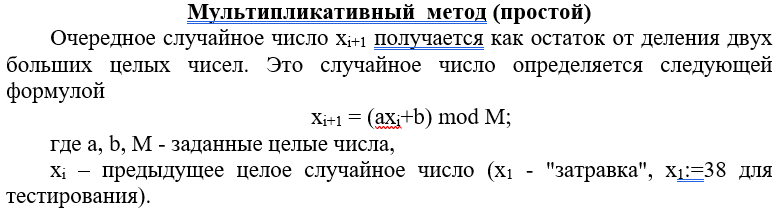
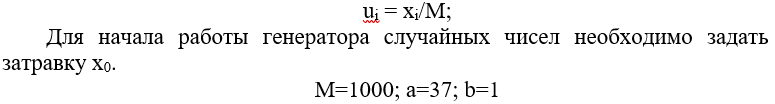

alpha = 0.05
x min x max


In [148]:
import math
import numpy as np

def MulRandGenerate(x0,a,b,N,M):
    arr = [x0]
    
    for _ in range(1,N):
       arr.append((a * arr[-1] + b) % M)
    
    transArr = np.array([x / M for x in arr])
    
    return transArr


M = 1000
a = 37
b = 1
N = 100
x0 = 38

randArr = MulRandGenerate(x0,a,b,N,M) 

print(randArr)

[0.038 0.407 0.06  0.221 0.178 0.587 0.72  0.641 0.718 0.567 0.98  0.261
 0.658 0.347 0.84  0.081 0.998 0.927 0.3   0.101 0.738 0.307 0.36  0.321
 0.878 0.487 0.02  0.741 0.418 0.467 0.28  0.361 0.358 0.247 0.14  0.181
 0.698 0.827 0.6   0.201 0.438 0.207 0.66  0.421 0.578 0.387 0.32  0.841
 0.118 0.367 0.58  0.461 0.058 0.147 0.44  0.281 0.398 0.727 0.9   0.301
 0.138 0.107 0.96  0.521 0.278 0.287 0.62  0.941 0.818 0.267 0.88  0.561
 0.758 0.047 0.74  0.381 0.098 0.627 0.2   0.401 0.838 0.007 0.26  0.621
 0.978 0.187 0.92  0.041 0.518 0.167 0.18  0.661 0.458 0.947 0.04  0.481
 0.798 0.527 0.5   0.501]


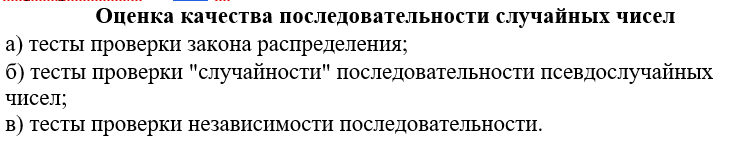

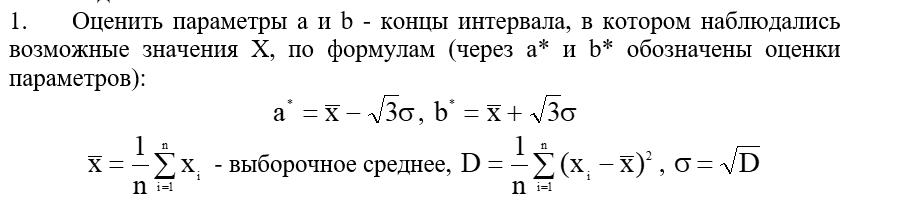

In [149]:
x_max, x_min = np.max(randArr), np.min(randArr)

s = round(1 + 3.322 * np.log10(N))
h = (x_max - x_min) / (1 + 3.3221 * np.log10(N))

print(F"Количество интервалов s: {s}")
print(F"Длина интервала h: {h}")
print(F"Диапазон: [{x_min},{x_max}]")

edges = np.array([x_min + i * h for i in range(s + 1)])

print(F"\nГраницы интервалов:")
for i in range(s):
    print(f"[{round(edges[i],4)}; {round(edges[i+1],4)})")

x_mean = np.sum(randArr) / N

D = np.sum((randArr - x_mean)**2) / (N - 1)
sigma = np.sqrt(D)

a_star = x_mean - np.sqrt(3) * sigma
b_star = x_mean + np.sqrt(3) * sigma

print(f"\nВыборочное среднее: {x_mean}")
print(f"\nСреднеквадратичное отклонение(Выборочная дисперсия): {sigma}")
print(f"\nОценка параметров: a* = {a_star}, b* = {b_star}")

Количество интервалов s: 8
Длина интервала h: 0.12964077339682373
Диапазон: [0.007,0.998]

Границы интервалов:
[0.007; 0.1366)
[0.1366; 0.2663)
[0.2663; 0.3959)
[0.3959; 0.5256)
[0.5256; 0.6552)
[0.6552; 0.7848)
[0.7848; 0.9145)
[0.9145; 1.0441)

Выборочное среднее: 0.46149999999999997

Среднеквадратичное отклонение(Выборочная дисперсия): 0.2798290423263692

Оценка параметров: a* = -0.023178118742613274, b* = 0.9461781187426133


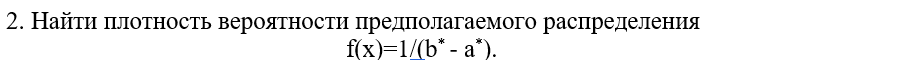
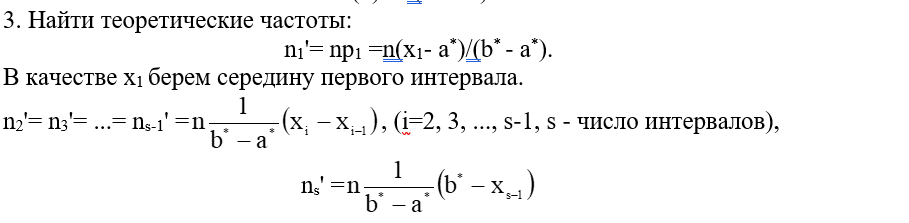

In [150]:

n_i, _ = np.histogram(randArr, bins=edges)


print("\nНаблюдаемые частоты:", n_i)

midpoints = (edges[:-1] + edges[1:]) / 2

ni_prime = []

# n1
n1 = N * (midpoints[0] - a_star) / (b_star - a_star)
ni_prime.append(n1)

# n2
for i in range(1, s - 1):
    ni = N * (midpoints[i] - midpoints[i - 1]) / (b_star - a_star)
    ni_prime.append(ni)

# ns'
ns = N * (b_star - midpoints[-2]) / (b_star - a_star)
ni_prime.append(ns)

ni_prime = np.array(ni_prime)

print("\nТеоретические частоты:", np.round(ni_prime, 4))

if np.any(n_i < 5):
    print("\nЕсть частоты < 5")
else:
    print("\nМалых частот (<5) нет")



Наблюдаемые частоты: [13 15 17 16 11 11  9  8]

Теоретические частоты: [ 9.8002 13.3739 13.3739 13.3739 13.3739 13.3739 13.3739  9.9564]

Малых частот (<5) нет


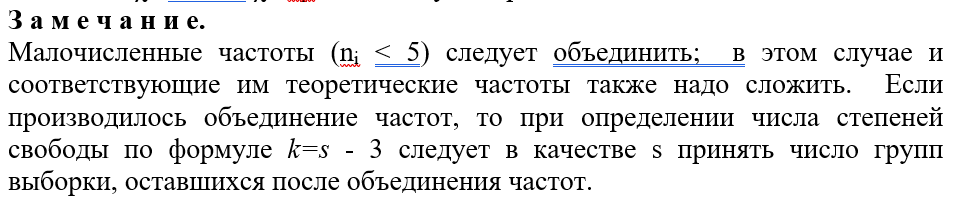

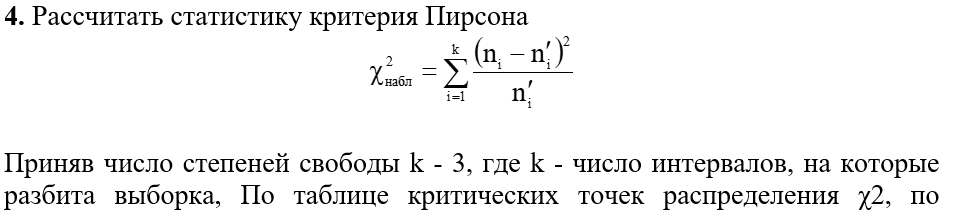
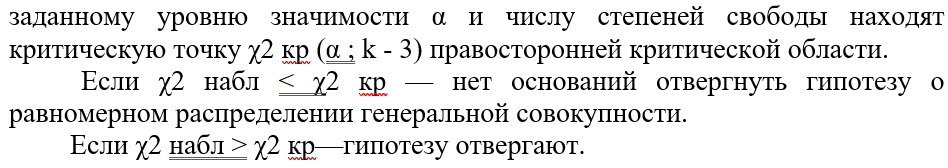

In [151]:
from scipy import stats

alpha = 0.05

chi2_obs = np.sum((n_i - ni_prime)**2 / ni_prime)

df = s - 3
chi2_crit = stats.chi2.ppf(1 - alpha, df)

print(f"Число степени свободы: {df}")
print(f"chi^2_набл = {chi2_obs}")
print(f"chi^2_кр(α={alpha}; df={df}) = {chi2_crit}")

print("Проверка гипотизы о равномерном распределение ген. свокупности")
if (chi2_obs < chi2_crit):
    print("Гипотиза подтвердилась")
else: print("Гипотиза отвергается")

Число степени свободы: 5
chi^2_набл = 5.39895027888965
chi^2_кр(α=0.05; df=5) = 11.070497693516351
Проверка гипотизы о равномерном распределение ген. свокупности
Гипотиза подтвердилась


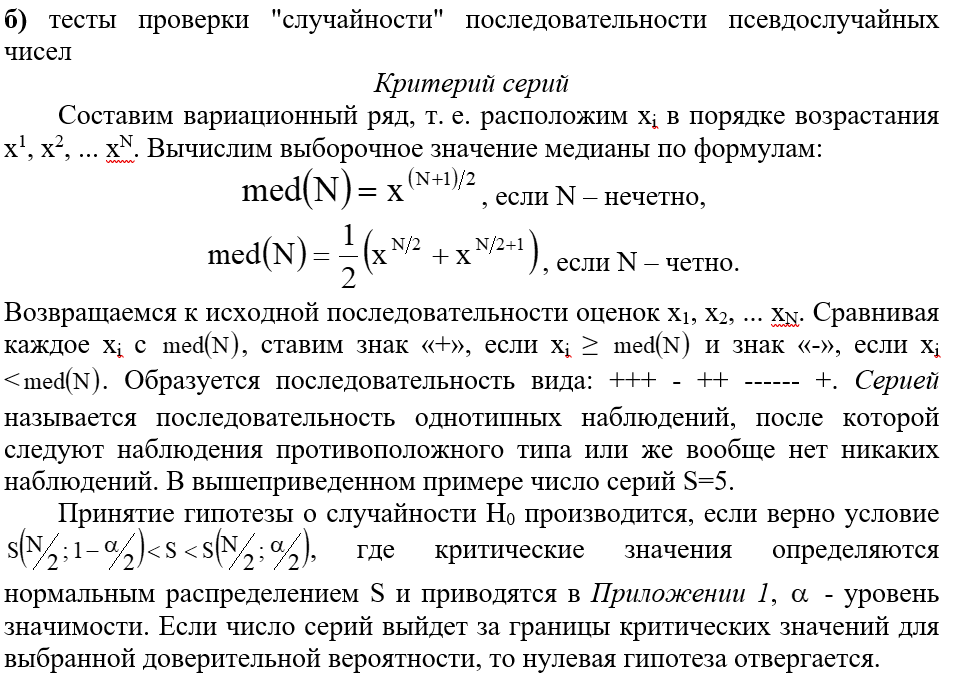

In [152]:
med = np.median(randArr)
signs = (randArr > med).astype(int) 

ser = []
for i in range(len(randArr)):
    if randArr[i] == med or randArr[i] > med:
        ser.append("+")
    else:
        ser.append("-")
print(ser)
if not ser:
    count = 0
else:
    count = 1
    for i in range(1, len(ser)):
        if ser[i] != ser[i - 1]:
            count += 1

print(f"Медиана выборки: {med}")
print(f"Количество серий (count): {count}")
if count > 40 and count < 59:
    print("Последовательность случайна")
else: print("Последовательность НЕ случайна")

['-', '-', '-', '-', '-', '+', '+', '+', '+', '+', '+', '-', '+', '-', '+', '-', '+', '+', '-', '-', '+', '-', '-', '-', '+', '+', '-', '+', '-', '+', '-', '-', '-', '-', '-', '-', '+', '+', '+', '-', '+', '-', '+', '-', '+', '-', '-', '+', '-', '-', '+', '+', '-', '-', '+', '-', '-', '+', '+', '-', '-', '-', '+', '+', '-', '-', '+', '+', '+', '-', '+', '+', '+', '-', '+', '-', '-', '+', '-', '-', '+', '-', '-', '+', '+', '-', '+', '-', '+', '-', '-', '+', '+', '+', '-', '+', '+', '+', '+', '+']
Медиана выборки: 0.4295
Количество серий (count): 54
Последовательность случайна


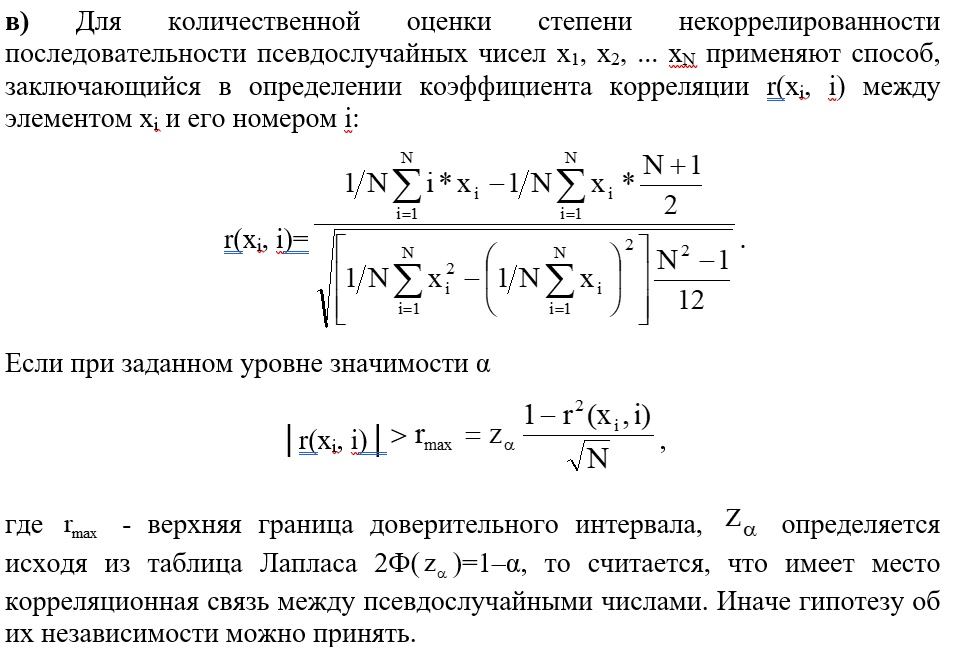

In [153]:
indices = np.arange(1, N + 1)
r, _ = stats.pearsonr(randArr, indices)

n = len(randArr)

# из таблица Лапласа
za = 2.24
r_max = za * ((1 -  r*r)/ math.sqrt(n))

print(f"Коэффициент корреляции r(x_i, i) = {r}")
print(f"r_max = {r_max}")
if r < r_max:
    print("Гипотезу об их независимости можно принять")
else: print("Считается, что имеет место корреляционная связь между псевдослучайными числами")

Коэффициент корреляции r(x_i, i) = 0.03673599960015659
r_max = 0.22369770445867654
Гипотезу об их независимости можно принять
